# Causes of Death Analysis: Infectious and Parasitic Diseases

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## Data Loading

In [16]:
import kagglehub
import os

path = kagglehub.dataset_download("imtkaggleteam/causes-of-death-in-world")
csv_path = os.path.join(path, "6- infectious-and-parasitic-diseases-death-rate-who-mdb.csv")

df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4707, 4)


,Entity,Code,Year,"Age-standardized deaths that are from infectious and parasitic diseases per 100,000 people, in both sexes aged all ages"
0,Albania,ALB,1987,13.346996
1,Albania,ALB,1988,11.110825
2,Albania,ALB,1989,15.654971
3,Albania,ALB,1992,9.986380
4,Albania,ALB,1993,13.130654


## Data Preprocessing

In [17]:
df = df.rename(columns={
    'Age-standardized deaths that are from infectious and parasitic diseases per 100,000 people, in both sexes aged all ages': 'DeathRate'
})
df.dtypes

Entity           str
Code             str
Year           int64
DeathRate    float64
dtype: object

In [18]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal missing DeathRate: {df['DeathRate'].isnull().sum()}")
print(f"Total missing Code: {df['Code'].isnull().sum()}")

=== Missing Values ===
Entity       0
Code         0
Year         0
DeathRate    0
dtype: int64

Total missing DeathRate: 0
Total missing Code: 0


In [19]:
df_clean = df.dropna(subset=['DeathRate']).copy()
df_clean['Year'] = df_clean['Year'].astype(int)
df_clean['DeathRate'] = df_clean['DeathRate'].astype(float)
print(f"Shape after cleaning: {df_clean.shape}")
print(f"\nData types:\n{df_clean.dtypes}")

Shape after cleaning: (4707, 4)

Data types:
Entity           str
Code             str
Year           int64
DeathRate    float64
dtype: object


## Exploratory Data Analysis

In [20]:
print(f"Shape: {df_clean.shape}")
print(f"Year range: {df_clean['Year'].min()} - {df_clean['Year'].max()}")
print(f"Unique countries: {df_clean['Entity'].nunique()}")
print(f"\nSummary Statistics")
df_clean['DeathRate'].describe()

Shape: (4707, 4)
Year range: 1950 - 2021
Unique countries: 116

Summary Statistics


count    4707.000000
mean       30.179093
std        45.863857
min         0.000000
25%         7.849647
50%        15.659326
75%        33.029280
max       656.613100
Name: DeathRate, dtype: float64

In [21]:
yearly_stats = df_clean.groupby('Year').agg({
    'DeathRate': ['mean', 'median', 'std', 'min', 'max', 'count']
}).round(2)
yearly_stats.columns = ['Mean', 'Median', 'Std', 'Min', 'Max', 'Count']
yearly_stats

,Mean,Median,Std,Min,Max,Count
Year,,,,,,
1950,83.00,54.11,82.08,35.11,293.08,9
1951,78.47,46.27,66.91,26.52,238.53,17
1952,64.72,38.57,54.57,23.47,206.01,18
1953,63.37,36.44,59.05,20.22,230.65,19
1954,54.69,32.14,50.55,18.20,191.52,20
...,...,...,...,...,...,...
2017,16.12,10.21,19.55,2.47,163.83,87
2018,15.61,10.61,18.48,2.07,150.10,81
2019,14.21,11.48,10.87,1.66,51.22,77


In [22]:
country_stats = df_clean.groupby('Entity').agg({
    'DeathRate': ['mean', 'std', 'min', 'max', 'count']
}).round(2)
country_stats.columns = ['Mean', 'Std', 'Min', 'Max', 'Count']
country_stats = country_stats.sort_values('Mean', ascending=False)
print("Top 10 Countries by Average Death Rate")
country_stats.head(10)

Top 10 Countries by Average Death Rate


,Mean,Std,Min,Max,Count
Entity,,,,,
South Africa,252.05,85.91,121.02,384.79,23
Sao Tome and Principe,201.41,25.41,181.50,230.03,3
Guatemala,190.07,187.26,25.11,656.61,53
Philippines,120.27,67.75,50.90,245.08,30
Cape Verde,94.46,55.41,55.28,133.65,2
Mexico,89.78,85.77,13.97,340.08,66
Colombia,74.46,75.46,12.37,230.65,59
Guyana,69.67,25.95,23.21,119.34,34
Fiji,67.71,11.11,55.12,91.74,12


In [23]:
print("Bottom 10 Countries by Average Death Rate")
country_stats.tail(10)

Bottom 10 Countries by Average Death Rate


,Mean,Std,Min,Max,Count
Entity,,,,,
Croatia,6.82,2.31,2.06,10.99,35
Luxembourg,6.75,2.85,2.15,13.35,55
Cyprus,6.54,2.46,2.54,11.48,19
Albania,6.20,4.25,1.21,15.65,22
Malta,5.66,3.44,0.97,21.66,52
Serbia,5.40,1.08,3.85,8.11,24
Czechia,4.91,2.50,2.24,9.25,36
Slovakia,4.49,1.46,2.80,8.50,26
Slovenia,4.25,1.56,1.74,7.87,36


## Visualization

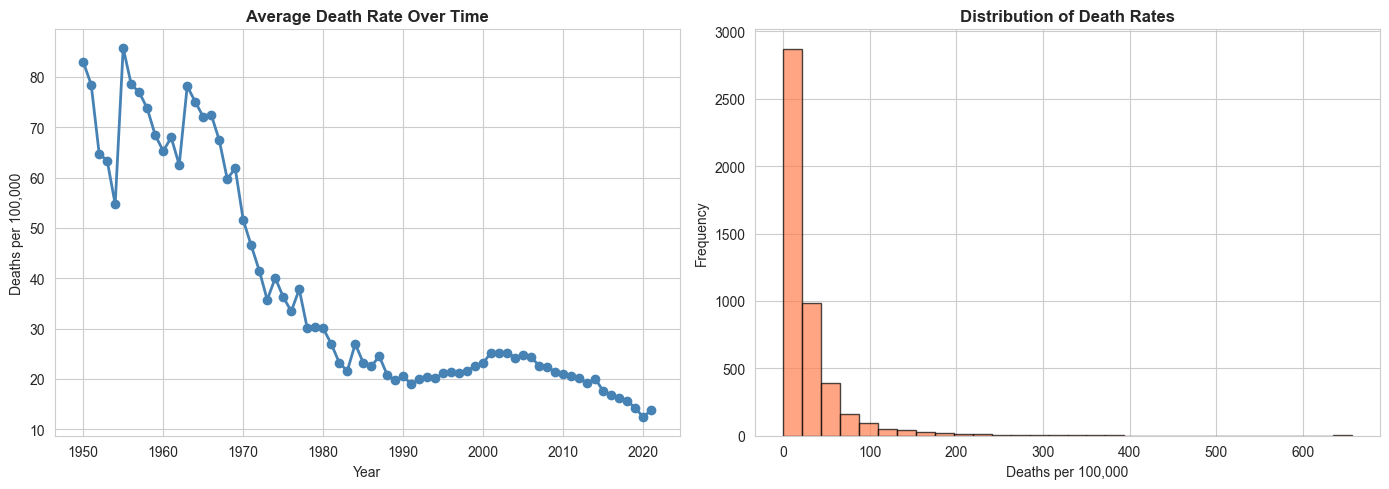

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

yearly_mean = df_clean.groupby('Year')['DeathRate'].mean()
axes[0].plot(yearly_mean.index, yearly_mean.values, marker='o', linewidth=2, color='steelblue')
axes[0].set_title('Average Death Rate Over Time', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Deaths per 100,000')

axes[1].hist(df_clean['DeathRate'], bins=30, edgecolor='black', color='coral', alpha=0.7)
axes[1].set_title('Distribution of Death Rates', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Deaths per 100,000')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

C:\Users\Marios\AppData\Local\Temp\ipykernel_32184\604843269.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Entity', y='DeathRate', palette='RdYlGn_r')


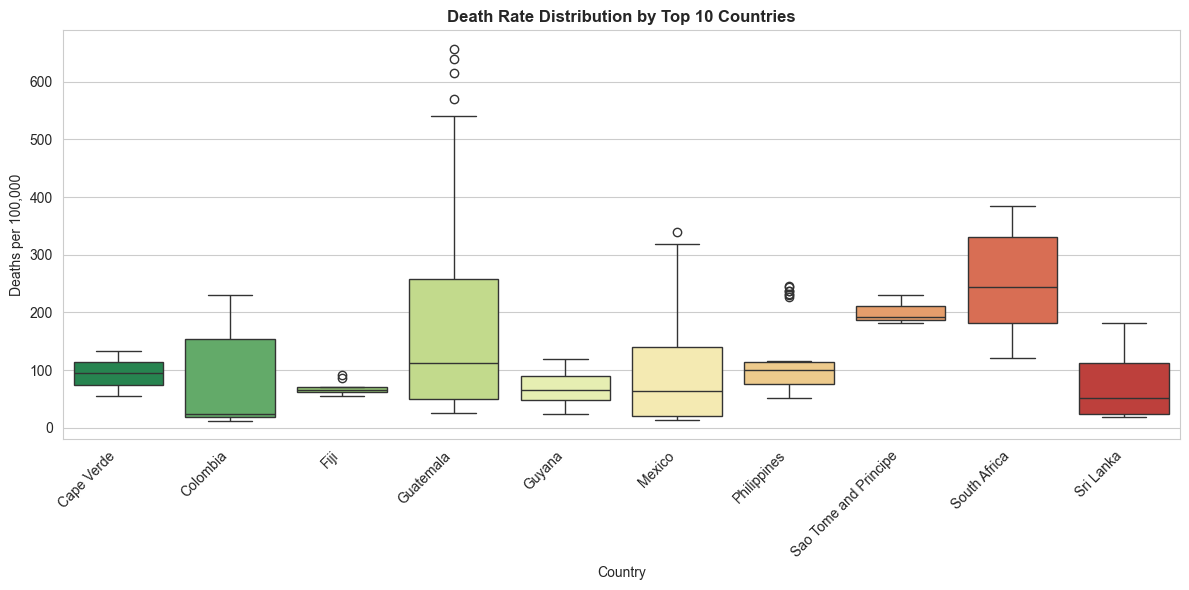

In [25]:
top_10_countries = country_stats.head(10).index.tolist()
df_top = df_clean[df_clean['Entity'].isin(top_10_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='Entity', y='DeathRate', palette='RdYlGn_r')
plt.title('Death Rate Distribution by Top 10 Countries', fontsize=12, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Deaths per 100,000')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

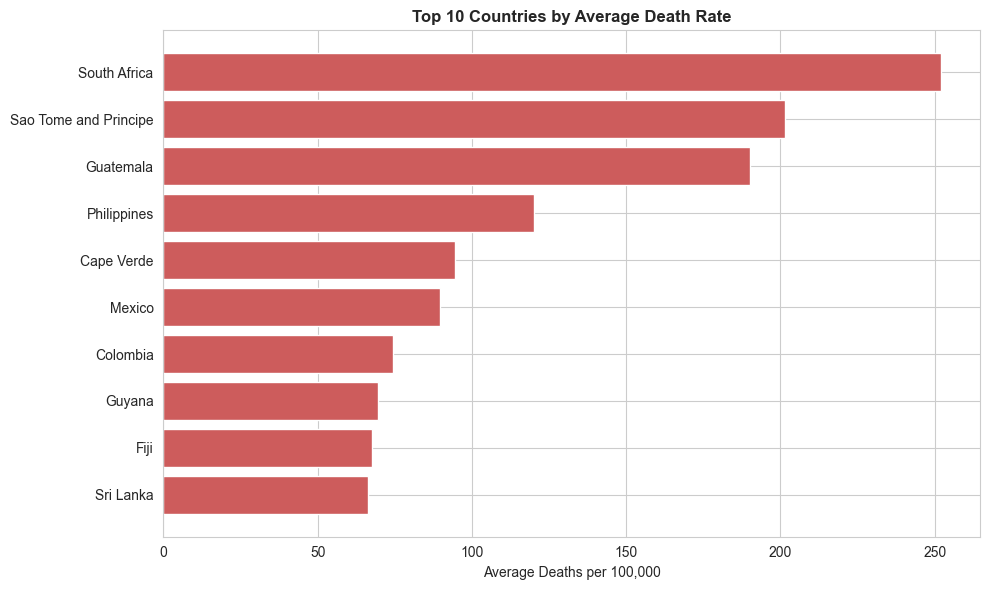

In [26]:
top_10 = country_stats.head(10).reset_index()
plt.figure(figsize=(10, 6))
plt.barh(top_10['Entity'], top_10['Mean'], color='indianred')
plt.xlabel('Average Deaths per 100,000')
plt.title('Top 10 Countries by Average Death Rate', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

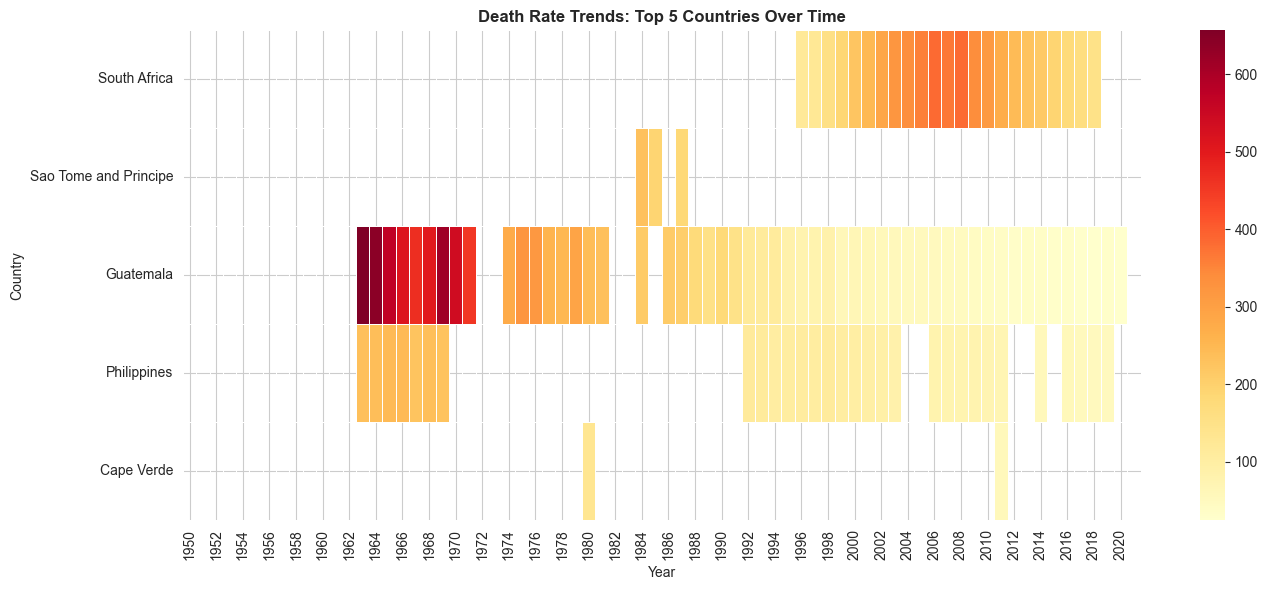

In [27]:
pivot_data = df_clean.pivot_table(values='DeathRate', index='Entity', columns='Year', aggfunc='mean')
top_5_countries = country_stats.head(5).index.tolist()
pivot_top5 = pivot_data.loc[top_5_countries]

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_top5, cmap='YlOrRd', linewidths=0.5, annot=False)
plt.title('Death Rate Trends: Top 5 Countries Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

## Summary

In [28]:
print(f"1. Dataset covers {df_clean['Year'].min()}-{df_clean['Year'].max()} with {df_clean['Entity'].nunique()} countries")
print(f"2. Average death rate globally: {df_clean['DeathRate'].mean():.2f} per 100,000")
print(f"3. Highest average: {country_stats.index[0]} ({country_stats.iloc[0]['Mean']:.2f})")
print(f"4. Lowest average: {country_stats.index[-1]} ({country_stats.iloc[-1]['Mean']:.2f})")
print(f"5. Trend: Death rates have {'decreased' if yearly_mean.iloc[-1] < yearly_mean.iloc[0] else 'increased'} from {yearly_mean.iloc[0]:.2f} to {yearly_mean.iloc[-1]:.2f}")

1. Dataset covers 1950-2021 with 116 countries
2. Average death rate globally: 30.18 per 100,000
3. Highest average: South Africa (252.05)
4. Lowest average: Montenegro (2.01)
5. Trend: Death rates have decreased from 83.00 to 13.87
